# Cinematic Kerr black hole renderer

Render a physically grounded black hole image directly in Google Colab. No local Python installation or GPU is required.

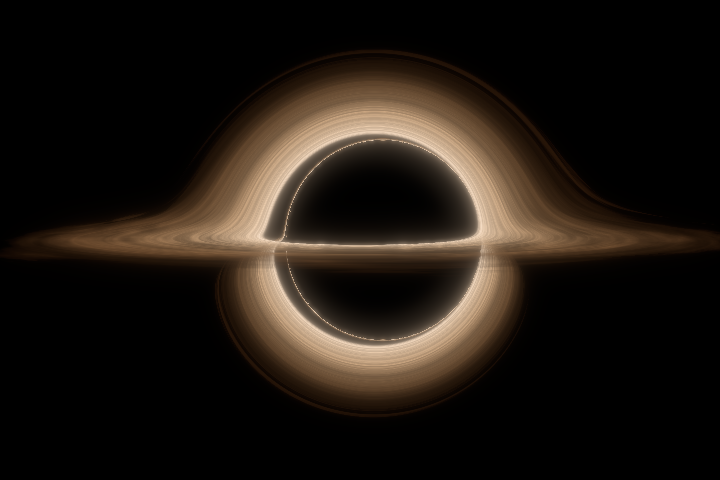

*Example output with the default cinematic settings.*

Run the cells from top to bottom, change the controls, and create your own view. The first render includes Numba compilation, so later renders in the same session are faster.

In [1]:
from pathlib import Path
import os
import subprocess
import sys

repo_url = "https://github.com/IakOBiaN/black-hole.git"
repo_dir = Path("/content/black-hole")

if not repo_dir.exists():
    subprocess.run(
        ["git", "clone", "--depth", "1", repo_url, str(repo_dir)],
        check=True,
    )

os.chdir(repo_dir)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "."], check=True)
print(f"Renderer ready in {repo_dir}")

Renderer ready in /content/black-hole


## Choose the view

The defaults produce a fast 720x480 preview. Increase the dimensions or supersampling only after the first successful render. `beautiful` emphasizes the cinematic finish, while `accurate` enables the implemented frequency shifts and relativistic beaming.

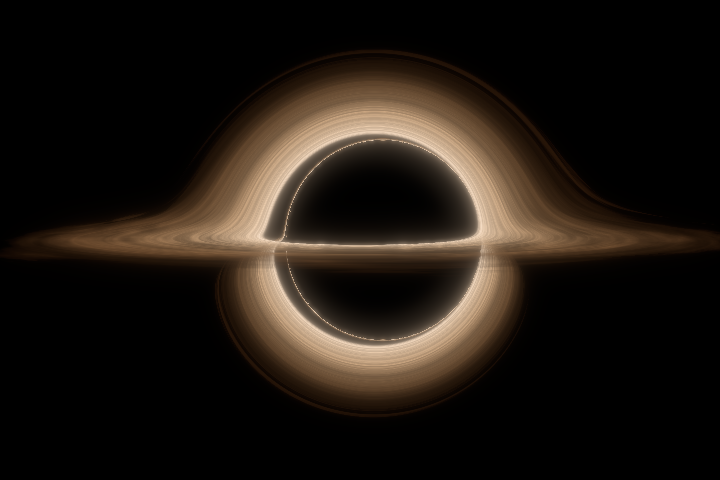

In [2]:
spin = 0.6  #@param {type:"slider", min:0, max:0.999, step:0.001}
mode = "beautiful"  #@param ["beautiful", "accurate"]
inclination = 3.44  #@param {type:"slider", min:0.1, max:90, step:0.1}
fov = 19.0  #@param {type:"slider", min:3, max:60, step:0.5}
azimuth = 0.0  #@param {type:"slider", min:0, max:360, step:1}
disk_time = 0.0  #@param {type:"number"}
width = 720  #@param {type:"integer"}
height = 480  #@param {type:"integer"}
supersample = 1  #@param [1, 2, 3]
max_steps = 6000  #@param {type:"integer"}

from IPython.display import display
from PIL import Image
from black_hole.snapshot import main as render_snapshot

output_path = repo_dir / "out" / "colab.png"
render_snapshot([
    "--spin", str(spin),
    "--mode", mode,
    "--inclination", str(inclination),
    "--fov", str(fov),
    "--azimuth", str(azimuth),
    "--time", str(disk_time),
    "--width", str(width),
    "--height", str(height),
    "--supersample", str(supersample),
    "--max-steps", str(max_steps),
    "--out", str(output_path),
])

with Image.open(output_path) as image:
    display(image.copy())

## Download the result

Run the cell below after rendering to save the full-resolution PNG to your device.

In [ ]:
from google.colab import files

files.download(str(output_path))